# logs2graph: scripts to convert girih based program logs to useful graphs

Fast travel:
 - [1st order rached  code](#1st_order)
 - [2nd order simwave code](#2nd_order)
 - [2nd order simwave code + CSV](#2nd_order+CSV)


## Importing logs

In [2]:
#imports libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import re

# Initialiser les listes pour stocker les données
timestamps = []
threads = []
tgs = []
num_wf = []
giga_flops = []

# Ouvrir et lire le fichier
/Users/pavelplotnitskii/Library/CloudStorage/Dropbox/PhD_proposal/work_with_david/Exawave_3_handover/logs/modelling.32876958.out
with open('/mnt/data/iter_full_param-results.txt', 'r') as file:
with open('/mnt/data/iter_full_param-results.txt', 'r') as file:
    for line in file:
        if '# THREADS' in line:
            threads.append(int(line.split()[-1]))
            timestamps.append(line.split(":")[1].strip())
        elif 'tgs' in line:
            tgs.append(int(re.search(r'tgs = (\d+)', line).group(1)))
            num_wf.append(int(re.search(r'num_wf = (\d+)', line).group(1)))
        elif 'GIGA FLOP / s' in line:
            giga_flops.append(float(line.split()[-1]))

# Créer un DataFrame à partir des listes
data = pd.DataFrame({
    'Timestamp': timestamps,
    'Threads': threads,
    'TGS': tgs,
    'NUM_WF': num_wf,
    'Giga_Flops': giga_flops
})

# Afficher les premières lignes de données
print(data.head())


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/iter_full_param-results.txt'

Import for **rached_1st** logs
<a id='1st_order'></a>

In [81]:
# Lists initialization
timestamps = []
threads = []
tgs = []
num_wf = []
giga_flops = []
giga_points = []
rms = []
mae = []
mre = []
max_diffs = []
elapsed_times = []

# Open & read logfile
with open('./datalogs/log-iter_param.log', 'r') as file:
    timestamp = thread = tgs_val = num_wf_val = giga_flops_val = giga_points_val = rms_val = mae_val = mre_val = max_diff = elapsed_time = None
    for line in file:
        if '# THREADS' in line:
            # Save previous data if it exists
            if timestamp is not None and thread is not None and tgs_val is not None and num_wf_val is not None and giga_flops_val is not None and giga_points_val is not None and elapsed_time is not None and max_diff is not None and mre_val is not None and mae_val is not None and rms_val is not None:
                timestamps.append(timestamp)
                threads.append(thread)
                tgs.append(tgs_val)
                num_wf.append(num_wf_val)
                giga_flops.append(giga_flops_val)
                giga_points.append(giga_points_val)
                rms.append(rms_val)
                mae.append(mae_val)
                mre.append(mre_val)
                max_diffs.append(max_diff)
                elapsed_times.append(elapsed_time)
                
            # Start new data row
            timestamp = line.split(":")[1].strip()
            thread = int(line.split()[-1])
            tgs_val = num_wf_val = giga_flops_val = giga_points_val = rms_val = mae_val = mre_val = max_diff = elapsed_time = None
        elif 'tgs = ' in line:
            tgs_val = int(re.search(r'tgs = (\d+)', line).group(1))
            num_wf_val = int(re.search(r'num_wf = (\d+)', line).group(1))
        elif 'GIGA FLOP / s' in line:
            giga_flops_val = float(line.split()[-1])
        elif 'GIGA POINT / s' in line:
            giga_points_val = float(line.split()[-1])
        elif 'RMS' in line:
            rms_val = float(line.split()[-1])
        elif 'MAE' in line:
            mae_val = float(line.split()[-1])
        elif 'MRE' in line:
            mre_val = float(line.split()[-1])
        elif 'MAX_DIFF' in line:
            max_diff = float(line.split()[-1])
        elif 'ELAPSED TIME (s)' in line:
            elapsed_time = float(line.split()[-1])
    
    # Save last row of data if it exists
    if timestamp is not None and thread is not None and tgs_val is not None and num_wf_val is not None and giga_flops_val is not None and giga_points_val is not None and elapsed_time is not None and max_diff is not None and mre_val is not None and mae_val is not None and rms_val is not None:
        timestamps.append(timestamp)
        threads.append(thread)
        tgs.append(tgs_val)
        num_wf.append(num_wf_val)
        giga_flops.append(giga_flops_val)
        giga_points.append(giga_points_val)
        rms.append(rms_val)
        mae.append(mae_val)
        mre.append(mre_val)
        max_diffs.append(max_diff)
        elapsed_times.append(elapsed_time)

# Create Dataframe
df = pd.DataFrame({
    'Timestamp': timestamps,
    'Threads': threads,
    'TGS': tgs,
    'NUM_WF': num_wf,
    'Giga_Flops': giga_flops,
    'Giga_Points': giga_points,
    'RMS': rms,
    'MAE': mae,
    'MRE': mre,
    'Max_Diff': max_diffs,
    'Elapsed_Time': elapsed_times
})

data = df
df.head()


,Timestamp,Threads,TGS,NUM_WF,Giga_Flops,Giga_Points,RMS,MAE,MRE,Max_Diff,Elapsed_Time
0,46,4,4,24,61.5532,1.43147,0.099491,0.000001,1.607980e+06,190.0,187.7120
1,51,4,4,32,60.6825,1.41122,0.099491,0.000001,1.607980e+06,190.0,190.4050
2,55,6,4,24,159.8310,3.71700,65326.100000,0.000012,1.000630e+00,259.0,72.2906
3,57,6,4,32,163.5430,3.80333,1.000000,0.004523,6.073080e+36,260.0,70.6496
4,00,8,4,24,160.8270,3.74017,65326.100000,0.000012,1.000630e+00,259.0,71.8427


In [60]:
data

,Threads,nb_core,MPoints/s,time,TGS,ntg,ncpus
0,4,4,1400.053671,384.998380,4,1,128
1,4,4,1559.399602,345.657646,4,1,128
2,4,4,1619.827740,332.762789,4,1,128
3,4,4,1775.246563,303.630159,4,1,128
4,8,8,3163.022277,170.412456,4,2,128
...,...,...,...,...,...,...,...
410,40,40,2339.925345,230.357091,40,1,128
411,40,40,3283.336349,164.167888,40,1,128
412,44,44,2486.264036,216.798533,44,1,128
413,44,44,2966.931768,181.675360,44,1,128


## Plots & Graphs

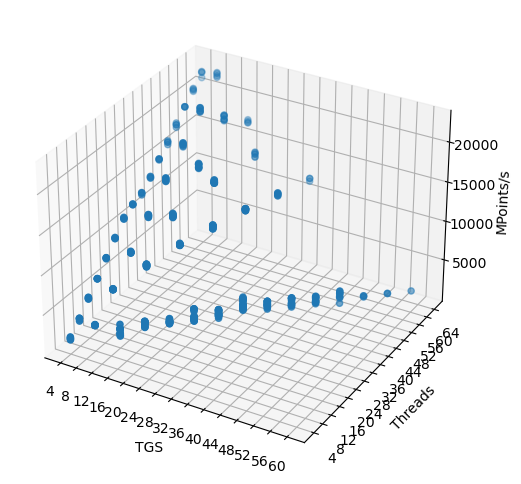

In [67]:
from mpl_toolkits.mplot3d import Axes3D

# Filter data for NUM_WF = 32
filtered_data = data#[data['NUM_WF'] == 32]

# Convert TGS and Threads to category for plotting
filtered_data['TGS'] = filtered_data['TGS'].astype('category')
filtered_data['Threads'] = filtered_data['Threads'].astype('category')

# Create 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Add data points
ax.scatter(filtered_data['TGS'].cat.codes, filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'])

# Set labels
ax.set_xlabel('TGS')
ax.set_ylabel('Threads')
ax.set_zlabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['TGS'].cat.categories)))
ax.set_xticklabels(filtered_data['TGS'].cat.categories)
ax.set_yticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_yticklabels(filtered_data['Threads'].cat.categories)

plt.show()


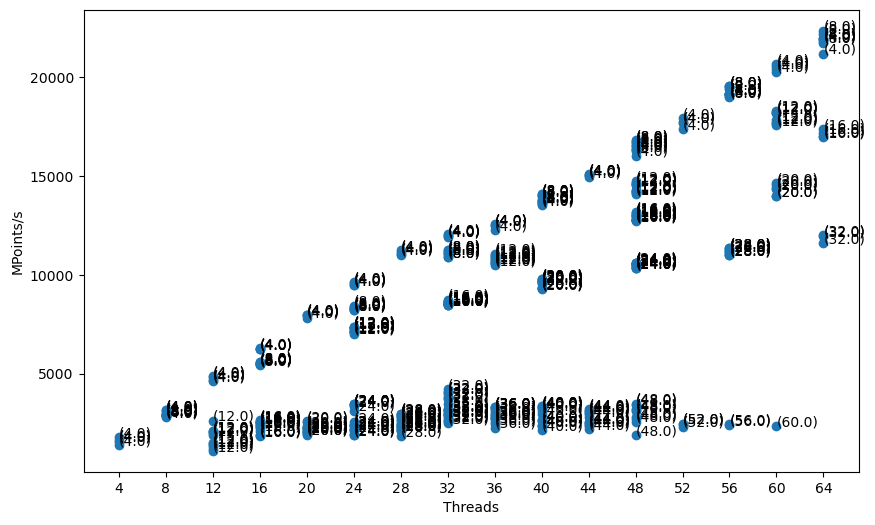

In [74]:
# Create 2D plot for the orthogonal projection
fig, ax = plt.subplots(figsize=(10, 6))

# Add data points
ax.scatter(filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'])

# Add labels for max points
for i, row in filtered_data.iterrows():
    thread_code = filtered_data['Threads'].cat.categories.tolist().index(row['Threads'])
    #ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {row["NUM_WF"]})')
    ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]})')

# Set labels
ax.set_xlabel('Threads')
ax.set_ylabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_xticklabels(filtered_data['Threads'].cat.categories)

plt.show()


In [34]:
# Initialize lists to store data
timestamps = []
threads = []
nb_cores = []
gpoints_s = []
times = []

# Open and read the file
with open('C:/Users/louis/Downloads/iter-2nd-kanary.log', 'r') as file:
    timestamp = thread = nb_core = gpoints_s_val = time = None
    for line in file:
        if 'PROGRAM CALL:' in line:
            # Save previous data if it exists
            if timestamp is not None and thread is not None and nb_core is not None and gpoints_s_val is not None and time is not None:
                timestamps.append(timestamp)
                threads.append(thread)
                nb_cores.append(nb_core)
                gpoints_s.append(gpoints_s_val)
                times.append(time)

            # Start new data row
            timestamp = line.split(":")[0].strip()
            tgs = int(re.search(r'--tb_thread_group_size (\d+)', line).group(1))
            ntg = int(re.search(r'--tb_nb_thread_groups (\d+)', line).group(1))
            thread = tgs * ntg
            nb_core = gpoints_s_val = time = None
        elif 'Metric  core:' in line:
            try:
                nb_core = int(line.split()[-1])
            except ValueError as e:
                print(f"Error extracting nb_core from line: {line}")
                print(f"Error message: {str(e)}")
        elif 'Main:' in line and 'Mstencils/s' in line:
            try:
                gpoints_s_val = float(line.split()[1])
            except ValueError as e:
                print(f"Error extracting GPoints/s from line: {line}")
                print(f"Error message: {str(e)}")
        elif 'mainloop:' in line and '(s)' in line:
            try:
                time = float(line.split()[1])
            except ValueError as e:
                print(f"Error extracting Time from line: {line}")
                print(f"Error message: {str(e)}")

    # Save last row of data if it exists
    if timestamp is not None and thread is not None and nb_core is not None and gpoints_s_val is not None and time is not None:
        timestamps.append(timestamp)
        threads.append(thread)
        nb_cores.append(nb_core)
        gpoints_s.append(gpoints_s_val)
        times.append(time)

# Create a DataFrame from the lists
data = pd.DataFrame({
    'Timestamp': timestamps,
    'Threads': threads,
    'Nb_Cores': nb_cores,
    'GPoints/s': gpoints_s,
    'Time': times
})

# Return the first few rows of data
data.head()


Error extracting Time from line: Wed Aug  2 17:17:54 +03 2023: [SIMWAVE MSG]:mainloop:     384.998380 (s) -099.62%

Error message: could not convert string to float: 'Aug'
Error extracting GPoints/s from line: Wed Aug  2 17:17:54 +03 2023: [SIMWAVE MSG]:Main:  1400.053671 Mstencils/s

Error message: could not convert string to float: 'Aug'
Error extracting Time from line: Wed Aug  2 17:24:07 +03 2023: [SIMWAVE MSG]:mainloop:     345.657646 (s) -099.59%

Error message: could not convert string to float: 'Aug'
Error extracting GPoints/s from line: Wed Aug  2 17:24:07 +03 2023: [SIMWAVE MSG]:Main:  1559.399602 Mstencils/s

Error message: could not convert string to float: 'Aug'
Error extracting Time from line: Wed Aug  2 17:30:05 +03 2023: [SIMWAVE MSG]:mainloop:     332.762789 (s) -099.59%

Error message: could not convert string to float: 'Aug'
Error extracting GPoints/s from line: Wed Aug  2 17:30:05 +03 2023: [SIMWAVE MSG]:Main:  1619.827740 Mstencils/s

Error message: could not conve

,Timestamp,Threads,Nb_Cores,GPoints/s,Time


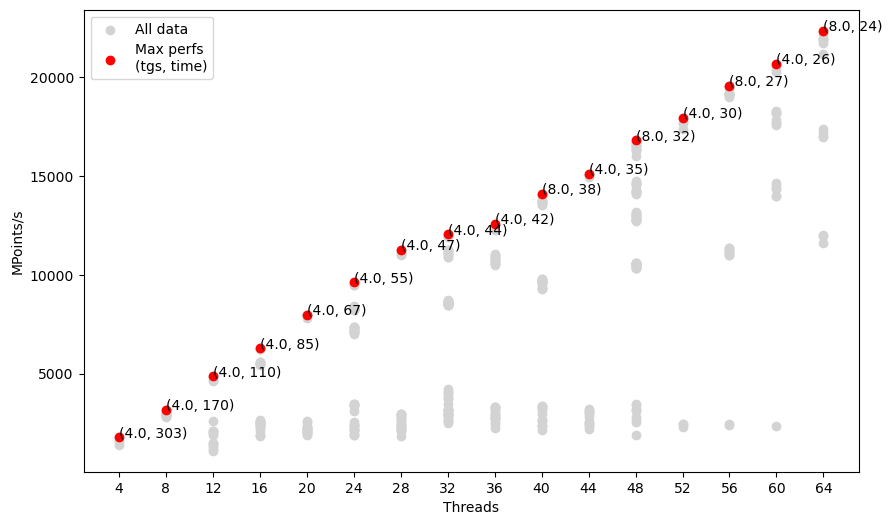

In [79]:
# Group by 'Threads' and find the row with the max 'Giga_Flops' for each group
max_rows = filtered_data.loc[filtered_data.groupby('Threads')['MPoints/s'].idxmax()]

# Create 2D plot for the orthogonal projection
fig, ax = plt.subplots(figsize=(10, 6))

# Add data points
ax.scatter(filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'], color='lightgrey')
ax.scatter(max_rows['Threads'].cat.codes, max_rows['MPoints/s'], color='red')

# Add labels for max points
for i, row in max_rows.iterrows():
    thread_code = filtered_data['Threads'].cat.categories.tolist().index(row['Threads'])
    #ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {row["NUM_WF"]})')
    ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {int(row["time"])})')

# Set labels
ax.set_xlabel('Threads')
ax.set_ylabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_xticklabels(filtered_data['Threads'].cat.categories)

# Add legend
ax.legend(['All data', 'Max perfs\n(tgs, time)'])

plt.show()


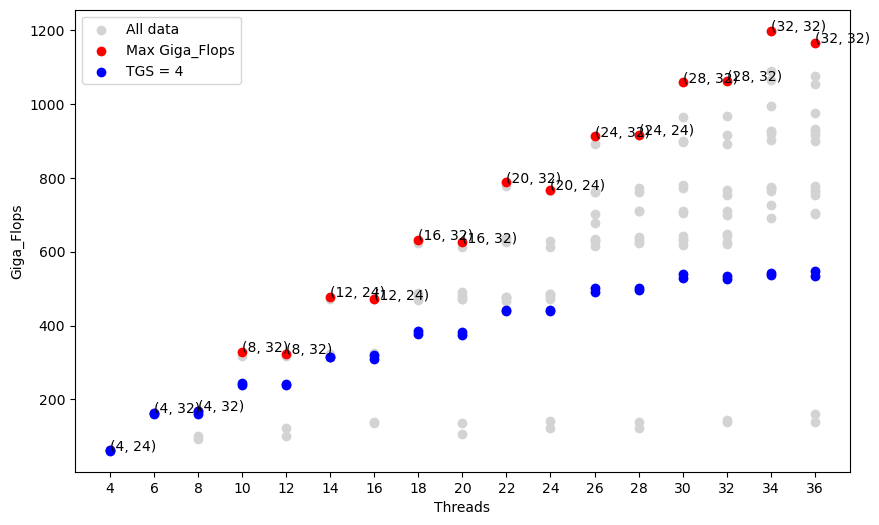

In [22]:
# Filter data for TGS = 4
tgs_4_data = filtered_data[filtered_data['TGS'] == 4]

# Create 2D plot for the orthogonal projection
fig, ax = plt.subplots(figsize=(10, 6))

# Add data points
ax.scatter(filtered_data['Threads'].cat.codes, filtered_data['Giga_Flops'], color='lightgrey')
ax.scatter(max_rows['Threads'].cat.codes, max_rows['Giga_Flops'], color='red')
ax.scatter(tgs_4_data['Threads'].cat.codes, tgs_4_data['Giga_Flops'], color='blue')

# Add labels for max points
for i, row in max_rows.iterrows():
    thread_code = filtered_data['Threads'].cat.categories.tolist().index(row['Threads'])
    ax.text(thread_code, row['Giga_Flops'], f'({row["TGS"]}, {row["NUM_WF"]})')

# Set labels
ax.set_xlabel('Threads')
ax.set_ylabel('Giga_Flops')

# Set tick labels
ax.set_xticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_xticklabels(filtered_data['Threads'].cat.categories)

# Add legend
ax.legend(['All data', 'Max Giga_Flops', 'TGS = 4'])

plt.show()


In [ ]:
# Create a new column for TGS and NUM_WF combinations
data['TGS_NUM_WF'] = data['TGS'].astype(str) + '-' + data['NUM_WF'].astype(str)

# Get unique thread counts
unique_threads = data['Threads'].unique()

# For each thread count, create a bar plot
for thread in unique_threads:
    # Filter data for the current thread count
    thread_data = data[data['Threads'] == thread]
    
    # Create the bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(thread_data['TGS_NUM_WF'], thread_data['Giga_Flops'])
    plt.title(f'Thread Count: {thread}')
    plt.xlabel('TGS-NUM_WF')
    plt.ylabel('Giga_Flops')
    plt.xticks(rotation=90)
    plt.show()


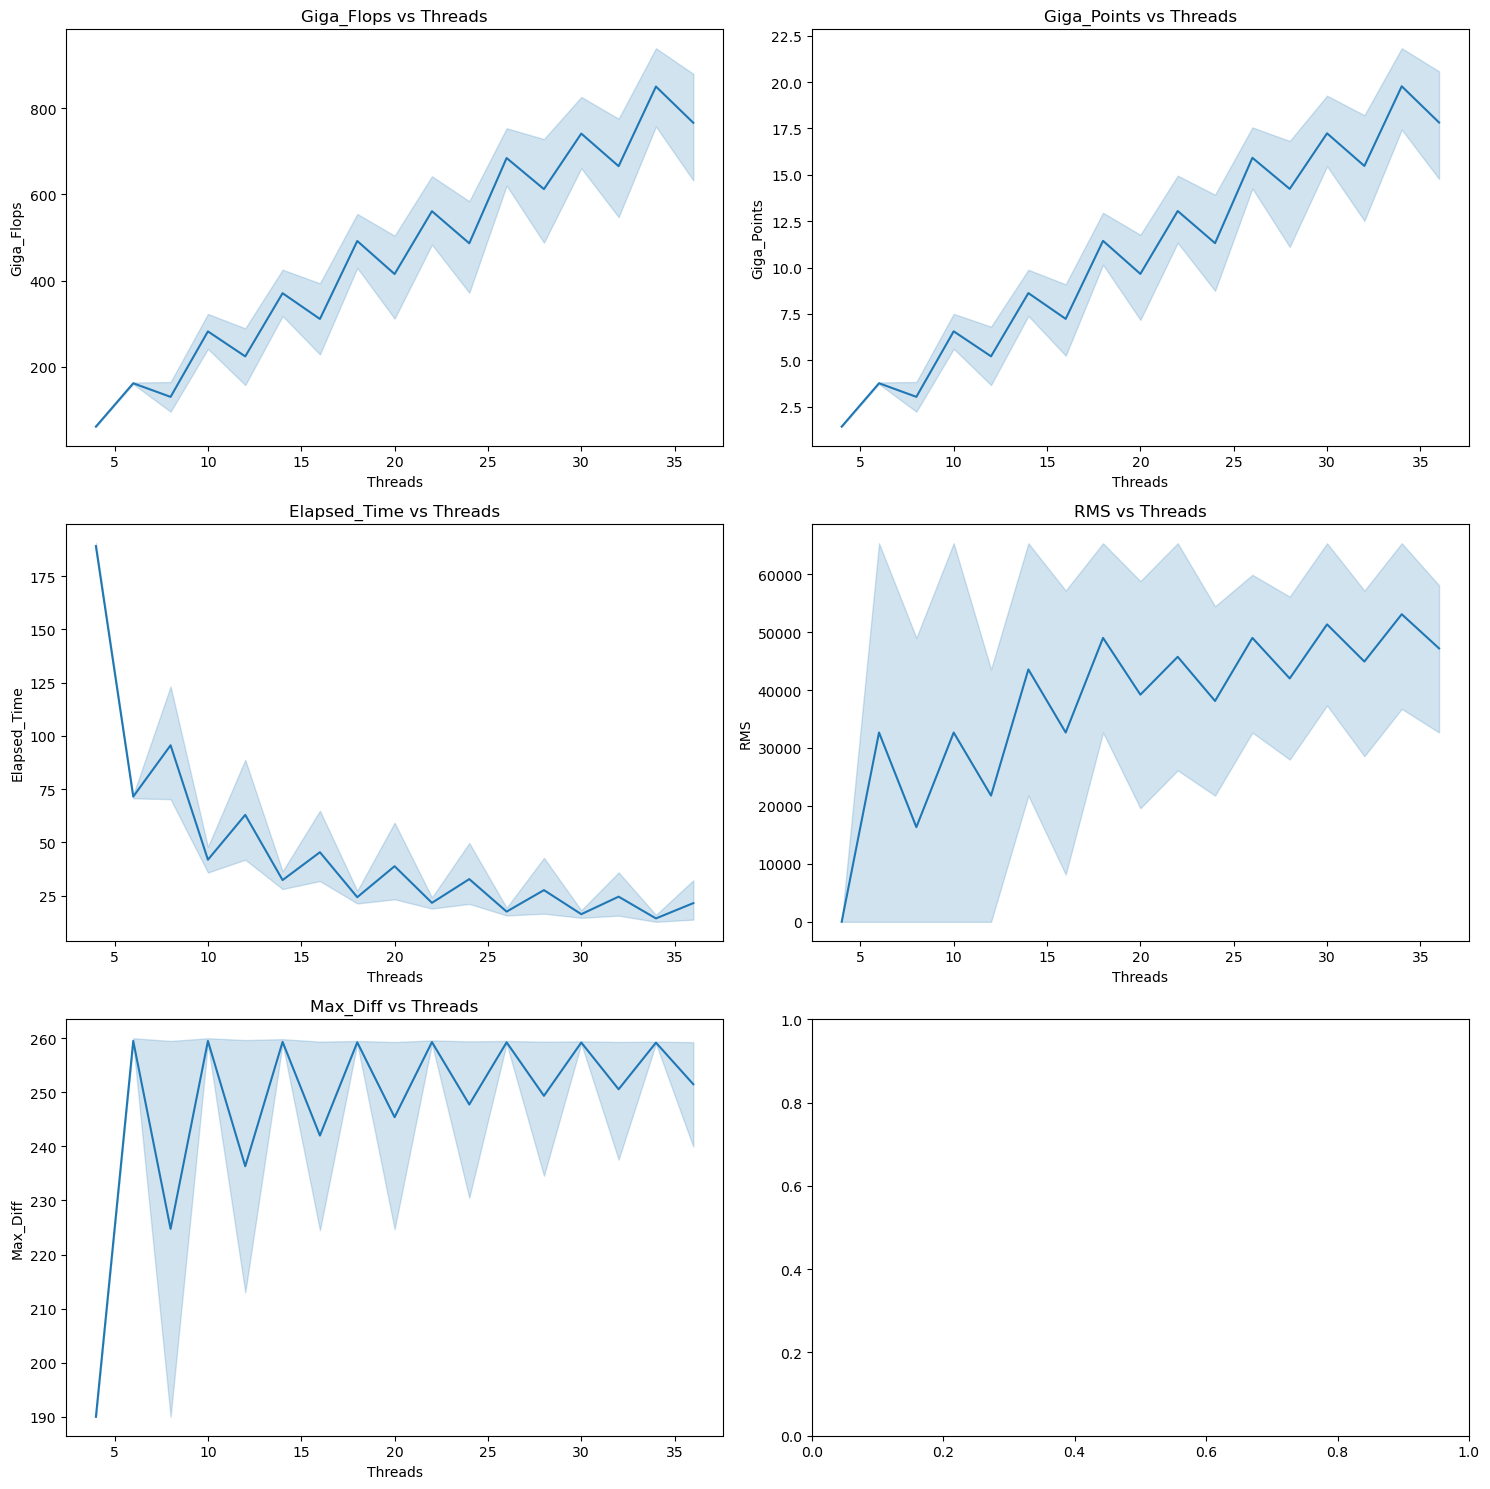

(           NUM_WF   Giga_Flops  Giga_Points           RMS         MAE  \
 count  162.000000   162.000000   162.000000    162.000000  162.000000   
 mean    28.000000   573.455888    13.336186  42744.483894    0.000808   
 std      4.012403   270.599031     6.293009  31164.381231    0.001559   
 min     24.000000    60.682500     1.411220      0.099491    0.000001   
 25%     24.000000   382.873500     8.904042      1.000000    0.000012   
 50%     28.000000   616.788500    14.343900  65326.100000    0.000012   
 75%     32.000000   763.858250    17.764175  65326.100000    0.000012   
 max     32.000000  1198.860000    27.880400  65326.100000    0.004523   
 
                 MRE    Max_Diff  Elapsed_Time  
 count  1.620000e+02  162.000000    162.000000  
 mean   7.838996e+35  251.567901     31.010501  
 std    1.816158e+36   21.839015     30.141192  
 min    1.000630e+00  190.000000      9.637730  
 25%    1.000630e+00  259.000000     15.126225  
 50%    1.000630e+00  259.000000     1

In [23]:
# Descriptive statistics
descriptive_stats = data.describe()

# Correlation matrix
correlation_matrix = data.corr()

# Plots to analyze scalability with respect to number of threads
fig, ax = plt.subplots(3, 2, figsize=(15, 15))

sns.lineplot(data=data, x="Threads", y="Giga_Flops", ax=ax[0, 0])
ax[0, 0].set_title("Giga_Flops vs Threads")

sns.lineplot(data=data, x="Threads", y="Giga_Points", ax=ax[0, 1])
ax[0, 1].set_title("Giga_Points vs Threads")

sns.lineplot(data=data, x="Threads", y="Elapsed_Time", ax=ax[1, 0])
ax[1, 0].set_title("Elapsed_Time vs Threads")

sns.lineplot(data=data, x="Threads", y="RMS", ax=ax[1, 1])
ax[1, 1].set_title("RMS vs Threads")

sns.lineplot(data=data, x="Threads", y="Max_Diff", ax=ax[2, 0])
ax[2, 0].set_title("Max_Diff vs Threads")

plt.tight_layout()
plt.show()

descriptive_stats, correlation_matrix


Import for **simwave** logs
<a id='2nd_order'></a>

In [93]:
data = {
    "Threads": [],
    "nb_core": [],
    "MPoints/s": [],
    "time": [],
    "TGS": [],
    "ntg": [],
    "ncpus": []
}

#with open("C:/Users/louis/Downloads/slurm-43222-fullsweepstoped_milan.out", "r") as file:
with open("C:/Users/louis/Downloads/slurm-43222-fullsweepstoped_milan.out", "r") as file:

    for line in file:
        if "ntg" in line and "tgs" in line:
            ntg = int(re.search(r'ntg (\d+)', line).group(1))
            tgs = int(re.search(r'tgs (\d+)', line).group(1))
            data["Threads"].append(ntg * tgs)
        
        if "Metric  core:" in line:
            nb_core = line.count('core') - 1 #-1 needed for reliable count
            data["nb_core"].append(nb_core)
        
        if "Main:" in line and "Mstencils/s" in line:
            gpoints = float(re.search(r'Main:  (\d+.\d+)', line).group(1))
            data["MPoints/s"].append(gpoints)
        
        if "mainloop:" in line and "(s)" in line:
            time = float(re.search(r'mainloop:     (\d+.\d+)', line).group(1))
            data["time"].append(time)
            
        if 'tgs' in line and 'ntg' in line:
            ntg_tgs = line.split(":")[-1].strip().split(",")
            ntg = int(ntg_tgs[0].split()[-1])
            tgs = int(ntg_tgs[1].split()[-1])
            data["ntg"].append(ntg)
            data["TGS"].append(tgs)
        if 'ncpus' in line:
            ncpus = int(line.split(":")[-1])
            data["ncpus"].append(ncpus)

#dict2dataframe
df = pd.DataFrame(data)

data = df
df.head()


,Threads,nb_core,MPoints/s,time,TGS,ntg,ncpus
0,4,4,587.041156,918.195240,4,1,128
1,4,4,574.144558,938.820003,4,1,128
2,4,4,587.317798,917.762747,4,1,128
3,4,4,583.861370,923.195853,4,1,128
4,4,4,564.049111,955.623164,4,1,128


In [94]:
data

,Threads,nb_core,MPoints/s,time,TGS,ntg,ncpus
0,4,4,587.041156,918.195240,4,1,128
1,4,4,574.144558,938.820003,4,1,128
2,4,4,587.317798,917.762747,4,1,128
3,4,4,583.861370,923.195853,4,1,128
4,4,4,564.049111,955.623164,4,1,128
...,...,...,...,...,...,...,...
595,44,44,5750.856456,93.728369,4,11,128
596,44,44,5713.317178,94.344210,4,11,128
597,44,44,5714.181419,94.329941,4,11,128
598,44,44,5715.499925,94.308180,4,11,128


## Plots & Graphs

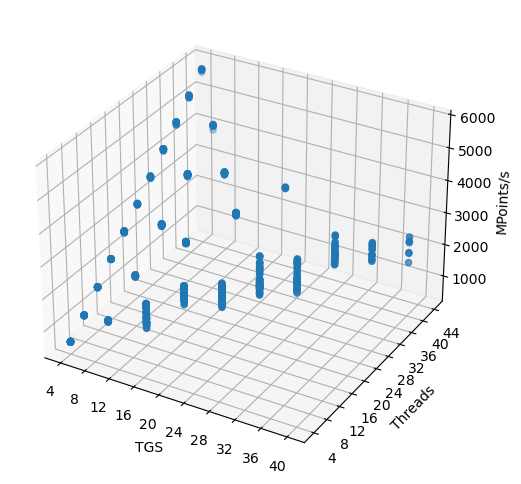

In [96]:
from mpl_toolkits.mplot3d import Axes3D

# Filter data for NUM_WF = 32
filtered_data = data#[data['NUM_WF'] == 32]

# Convert TGS and Threads to category for plotting
filtered_data['TGS'] = filtered_data['TGS'].astype('category')
filtered_data['Threads'] = filtered_data['Threads'].astype('category')

# Create 3D plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Add data points
ax.scatter(filtered_data['TGS'].cat.codes, filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'])

# Set labels
ax.set_xlabel('TGS')
ax.set_ylabel('Threads')
ax.set_zlabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['TGS'].cat.categories)))
ax.set_xticklabels(filtered_data['TGS'].cat.categories)
ax.set_yticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_yticklabels(filtered_data['Threads'].cat.categories)

plt.show()


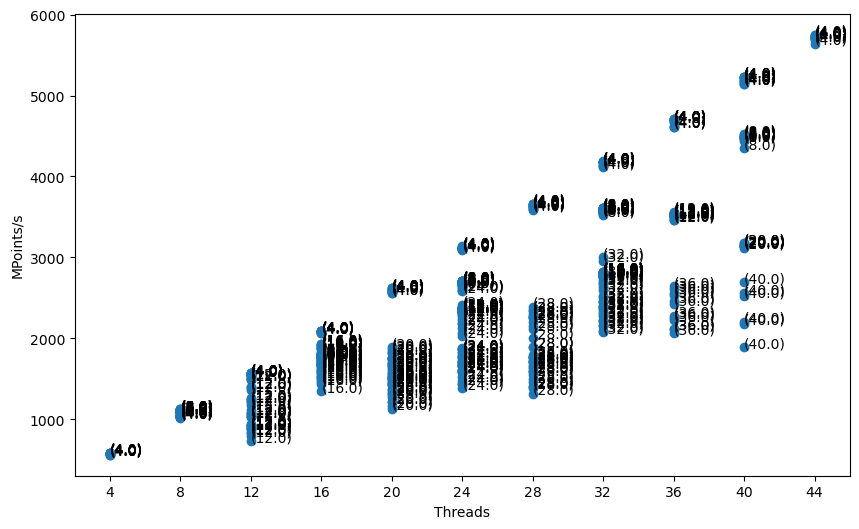

In [97]:
# Create 2D plot for the orthogonal projection
fig, ax = plt.subplots(figsize=(10, 6))

# Add data points
ax.scatter(filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'])

# Add labels for max points
for i, row in filtered_data.iterrows():
    thread_code = filtered_data['Threads'].cat.categories.tolist().index(row['Threads'])
    #ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {row["NUM_WF"]})')
    ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]})')

# Set labels
ax.set_xlabel('Threads')
ax.set_ylabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_xticklabels(filtered_data['Threads'].cat.categories)

plt.show()


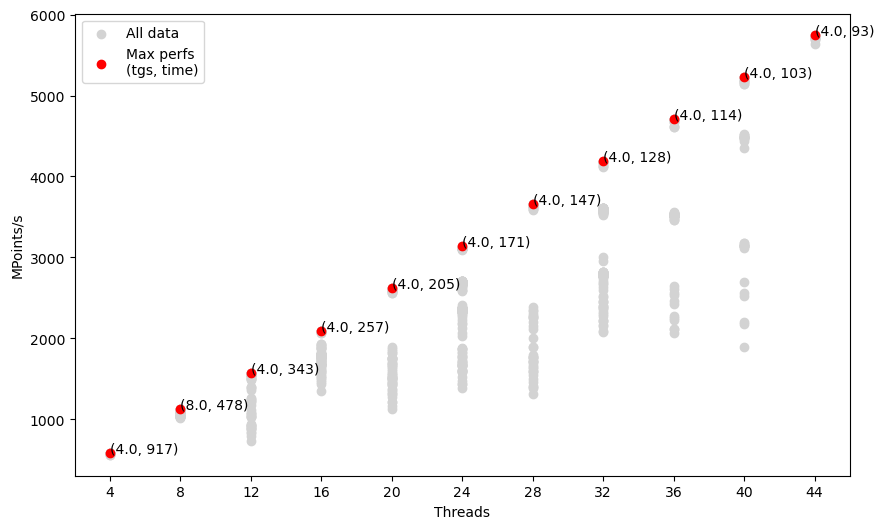

In [98]:
# Group by 'Threads' and find the row with the max 'Giga_Flops' for each group
max_rows = filtered_data.loc[filtered_data.groupby('Threads')['MPoints/s'].idxmax()]

# Create 2D plot for the orthogonal projection
fig, ax = plt.subplots(figsize=(10, 6))

# Add data points
ax.scatter(filtered_data['Threads'].cat.codes, filtered_data['MPoints/s'], color='lightgrey')
ax.scatter(max_rows['Threads'].cat.codes, max_rows['MPoints/s'], color='red')

# Add labels for max points
for i, row in max_rows.iterrows():
    thread_code = filtered_data['Threads'].cat.categories.tolist().index(row['Threads'])
    #ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {row["NUM_WF"]})')
    ax.text(thread_code, row['MPoints/s'], f'({row["TGS"]}, {int(row["time"])})')

# Set labels
ax.set_xlabel('Threads')
ax.set_ylabel('MPoints/s')

# Set tick labels
ax.set_xticks(range(len(filtered_data['Threads'].cat.categories)))
ax.set_xticklabels(filtered_data['Threads'].cat.categories)

# Add legend
ax.legend(['All data', 'Max perfs\n(tgs, time)'])

plt.show()


Import for **simwave** logs with CSV
<a id='2nd_order+CSV'></a>

In [9]:
import pandas as pd

flag_csv = 0

# Initialize lists to store extracted data
parameters = []
performances = []

# Open the file and read its content line by line
with open("C:/Users/louis/OneDrive/Documents/1_Travail/5A/Stage-Algodoers/resultats/simwave-TB-milan/simwave-tb-qaysar.log", "r") as file:
    for line in file:
        # Identify lines starting with "CSV:" to extract the parameters
        if "CSV:" in line:
            if flag_csv==0:
                flag_csv=1
                continue
            # Split the line and extract the values after "CSV:"
            params = line.split("CSV:")[1].strip().split(";")
            parameters.append(params)
        # Identify lines containing "[SIMWAVE MSG]:" to extract the performance in Mstencils/s
        elif ":Main:" in line:
            perf = float(line.split("Mstencils/s")[0].split()[-1])
            performances.append(perf)

# Separate the parameters into two lists (since there are two performance values for each set of parameters)
params_list = [parameters[i] for i in range(len(parameters)) for _ in (0, 1)]

# Create a dataframe from the extracted data
df = pd.DataFrame(params_list, columns=["size", "timesteps", "OMP_NUM_THREADS", "tgs", "ntg", "th_xyz", "t_dim", "num_wf", "mode", "tb_or_sb"])
df["performance"] = performances

df


,size,timesteps,OMP_NUM_THREADS,tgs,ntg,th_xyz,t_dim,num_wf,mode,tb_or_sb,performance
0,512,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1296.153515
1,512,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1294.810237
2,1024,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1186.254417
3,1024,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1188.509210
4,2048,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1203.942245
...,...,...,...,...,...,...,...,...,...,...,...
127,512,1000,28,16,1,"(1, 2, 8)",3,21,2,tb,2727.353187
128,1024,1000,28,16,1,"(1, 2, 8)",3,21,2,tb,2634.871052
129,1024,1000,28,16,1,"(1, 2, 8)",3,21,2,tb,2639.910882
130,2048,1000,28,16,1,"(1, 2, 8)",3,21,2,tb,2618.837011


In [10]:
# Add a column to specify whether the run used first touch or not
df["first_touch"] = [i % 2 == 1 for i in range(len(df))]

# Display the updated dataframe
df.head()


,size,timesteps,OMP_NUM_THREADS,tgs,ntg,th_xyz,t_dim,num_wf,mode,tb_or_sb,performance,first_touch
0,512,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1296.153515,False
1,512,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1294.810237,True
2,1024,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1186.254417,False
3,1024,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1188.509210,True
4,2048,1000,7,4,1,"(1, 2, 2)",3,21,2,tb,1203.942245,False


C:\Users\louis\Anaconda3\lib\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


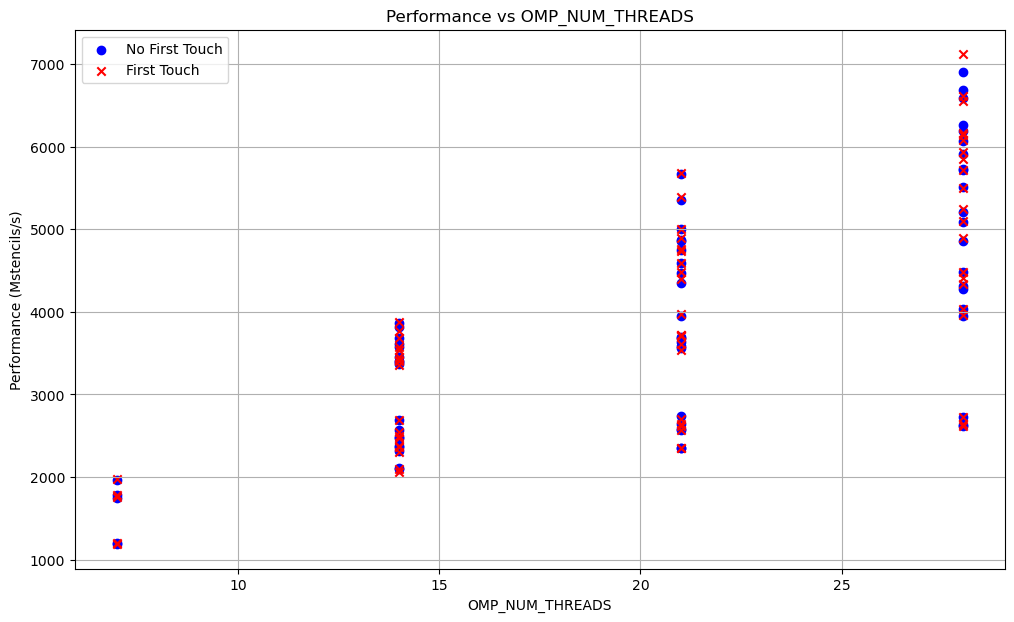

In [11]:
import matplotlib.pyplot as plt

# Remove the header row
df_cleaned = df[2:]

# Convert OMP_NUM_THREADS to int for plotting
df_cleaned["OMP_NUM_THREADS"] = df_cleaned["OMP_NUM_THREADS"].astype(int)

# Plot
plt.figure(figsize=(12, 7))

# Plot runs without first touch
plt.scatter(df_cleaned[df_cleaned["first_touch"] == False]["OMP_NUM_THREADS"],
            df_cleaned[df_cleaned["first_touch"] == False]["performance"],
            marker='o', color='blue', label='No First Touch')

# Plot runs with first touch
plt.scatter(df_cleaned[df_cleaned["first_touch"] == True]["OMP_NUM_THREADS"],
            df_cleaned[df_cleaned["first_touch"] == True]["performance"],
            marker='x', color='red', label='First Touch')

plt.xlabel("OMP_NUM_THREADS")
plt.ylabel("Performance (Mstencils/s)")
plt.title("Performance vs OMP_NUM_THREADS")
plt.legend()
plt.grid(True)
plt.show()


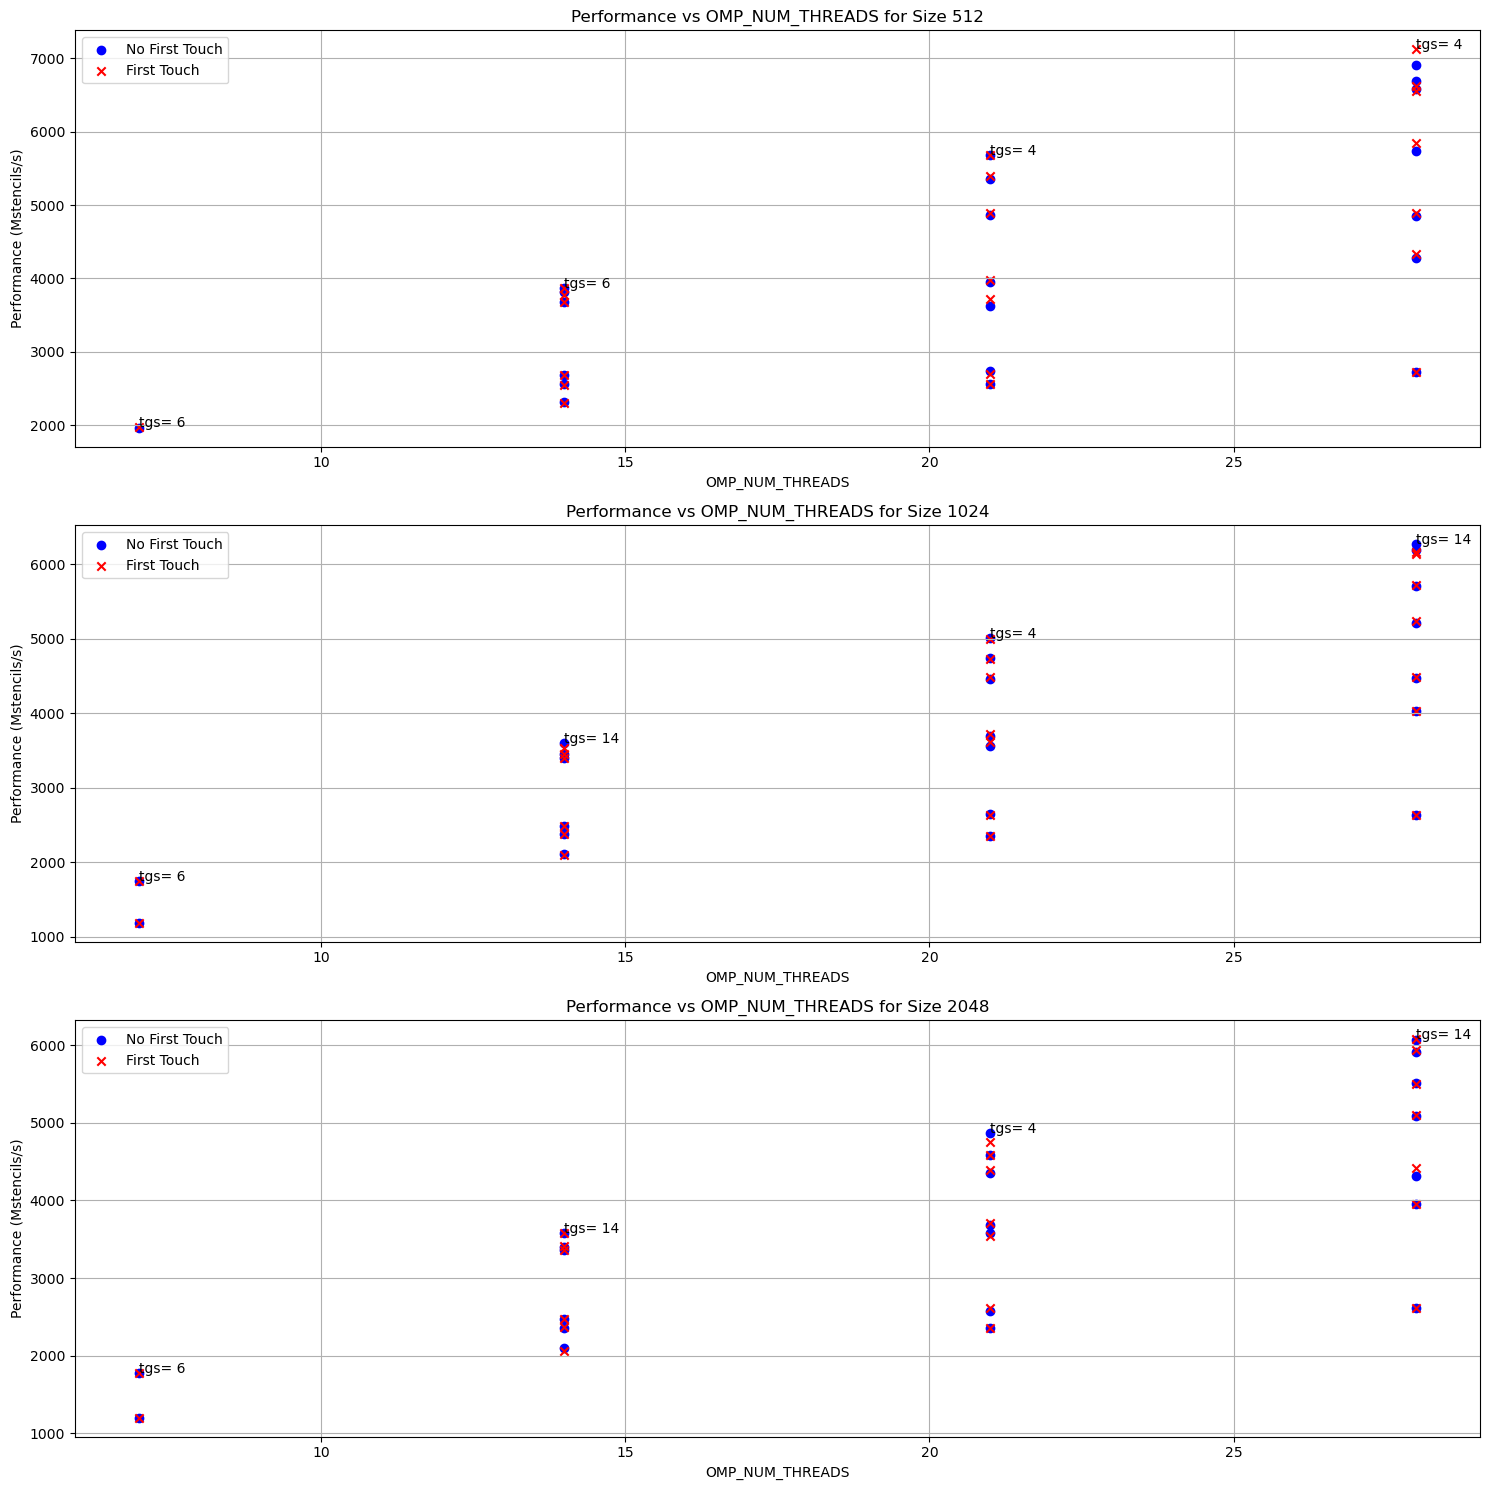

In [12]:
# Unique sizes
sizes = ['512', '1024', '2048']

# Plotting for each size again
plt.figure(figsize=(15, 15))

for idx, size in enumerate(sizes, 1):
    # Filter data by size
    df_size = df_cleaned[df_cleaned['size'].str.strip() == size]
    
    # For each unique value of OMP_NUM_THREADS, identify the highest performance value
    max_performances = df_size.groupby('OMP_NUM_THREADS')['performance'].max()
    
    plt.subplot(3, 1, idx)
    
    # Plot runs without first touch
    plt.scatter(df_size[df_size["first_touch"] == False]["OMP_NUM_THREADS"],
                df_size[df_size["first_touch"] == False]["performance"],
                marker='o', color='blue', label='No First Touch')

    # Plot runs with first touch
    plt.scatter(df_size[df_size["first_touch"] == True]["OMP_NUM_THREADS"],
                df_size[df_size["first_touch"] == True]["performance"],
                marker='x', color='red', label='First Touch')

    # Annotate highest performance values with tgs
    for omp_threads, performance in max_performances.items():
        tgs_value = df_size[(df_size['OMP_NUM_THREADS'] == omp_threads) & (df_size['performance'] == performance)]['tgs'].values[0]
        plt.annotate(f'tgs={tgs_value}', (omp_threads, performance))
    
    plt.xlabel("OMP_NUM_THREADS")
    plt.ylabel("Performance (Mstencils/s)")
    plt.title(f"Performance vs OMP_NUM_THREADS for Size {size}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.show()
